In [7]:
#---Online Retail store EDA--#
import pandas as pd

df = pd.read_csv(r"C:\Users\hites\online_retail.csv", encoding="latin1", low_memory=False)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [22]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [12]:
#Cleaning and adding column
d = df.copy()

# Clean text
d["Description"] = d["Description"].str.strip().str.upper()

# Convert date
d["InvoiceDate"] = pd.to_datetime(d["InvoiceDate"], errors="coerce")

# Create revenue column
d["Revenue"] = d["Quantity"] * d["Price"]

# Remove cancelled orders and returns
d = d[d["Quantity"] > 0]
d = d[~d["Invoice"].astype(str).str.startswith("C")]

d.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [15]:
#(1)Identify Frequently Co-Purchased Products
basket = d.groupby("Invoice")["Description"].apply(list)

pairs = {}

for items in basket:
    
    items = list(set(items))   # remove duplicates
    
    for i in range(len(items)):
        for j in range(i+1, len(items)):
            
            pair = (items[i], items[j])
            
            if pair in pairs:
                pairs[pair] += 1
            else:
                pairs[pair] = 1

pair_list = []

for pair,count in pairs.items():
    pair_list.append([pair[0], pair[1], count])

top_pairs = pd.DataFrame(pair_list, columns=["Product_A","Product_B","Count"])

top_pairs.sort_values("Count", ascending=False).head(20)

,Product_A,Product_B,Count
80775,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,765
261,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,639
964554,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,629
5797,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,553
7137,LUNCH BAG RED RETROSPOT,LUNCH BAG BLACK SKULL.,532
386,JUMBO STORAGE BAG SUKI,JUMBO BAG PINK POLKADOT,515
17359,JUMBO SHOPPER VINTAGE RED PAISLEY,JUMBO BAG RED RETROSPOT,506
11587,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,503
2667237,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,498
2796,LUNCH BAG RED RETROSPOT,LUNCH BAG PINK POLKADOT,497


In [ ]:
#Market basket analysis revealed that certain products are frequently purchased together within the same transaction. 
#These co-purchase relationships indicate strong associations between items and can be used to recommend complementary products.

Month
1      691364.560
2      523631.890
3      717639.360
4      537808.621
5      770536.020
6      761739.900
7      719221.191
8      737014.260
9     1058590.172
10    1154979.300
11    1509496.330
12    1462556.820
Name: Revenue, dtype: float64


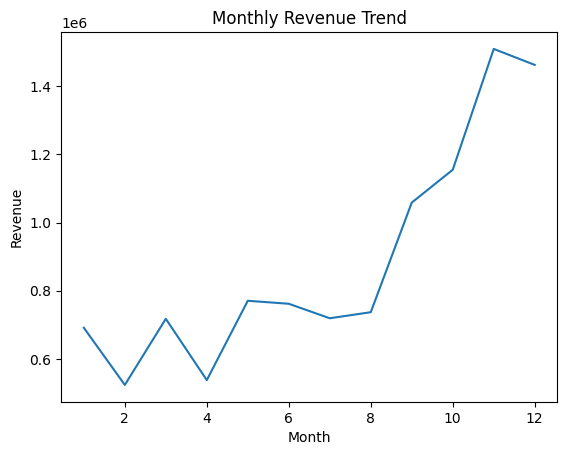

In [16]:
#(2)Seasonal Demand Analysis
import matplotlib.pyplot as plt

# Extract month
d["Month"] = d["InvoiceDate"].dt.month

monthly_sales = d.groupby("Month")["Revenue"].sum()

print(monthly_sales)

plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [ ]:
##(2)Seasonal Demand Analysis
#Time-series analysis of monthly sales demonstrated that product demand varies throughout the year. 
#Certain months show higher revenue due to seasonal purchasing behavior.
#Identifying these peak periods allows businesses to plan targeted marketing campaigns, adjust inventory levels, 
#and promote products that are more likely to sell during specific seasons.

In [17]:
#Regional Demand Analysis
country_sales = d.groupby("Country")["Revenue"].sum()

country_sales = country_sales.sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    9003097.964
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209733.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

In [ ]:
#Regional Demand Patterns
#Country-level sales analysis highlighted that demand differs significantly across geographic regions. 
#Some products are more popular in specific countries, indicating regional preferences. 
#These insights allow businesses to provide location-based recommendations and tailor marketing strategies for different markets.

In [18]:
#(3)Detect High-Return 
sales = df[df["Quantity"] > 0].groupby("Description")["Quantity"].sum()

returns = df[df["Quantity"] < 0].groupby("Description")["Quantity"].sum().abs()

return_rate = (returns / sales).fillna(0)

product_revenue = df[df["Quantity"] > 0].groupby("Description")["Price"].sum()

risk_df = pd.DataFrame({
    "Revenue": product_revenue,
    "ReturnRate": return_rate
}).fillna(0)

risk_df.sort_values("ReturnRate", ascending=False).head(20)

,Revenue,ReturnRate
Description,,
SAMPLES,63.050,30.500000
AMAZON FEE,13761.090,16.000000
check,0.000,10.884963
damaged,0.000,9.500000
BLUE PADDED SOFT MOBILE,4.250,7.000000
PINK POODLE HANGING DECORATION,6.720,2.400000
Bank Charges,165.001,2.083333
PINK CHERRY LIGHTS,6.750,2.000000
WOODEN BOX ADVENT CALENDAR,44.750,1.600000


In [ ]:
#Recency (R)
#Recency measures how recently a customer made their last purchase.
#Customers with low recency are more likely to respond to recommendations or promotions.

#Frequency(F)
#Frequency measures how often a customer makes purchases.
#Frequent buyers are more valuable customers and good candidates for upselling.

#Monetary (M)
#Monetary value measures how much money a customer spends.
#High monetary customers are important for business revenue and should receive personalized recommendations.

#RFM Scoring
#Each customer is scored based on Recency, Frequency, and Monetary.
#Higher score = better customer value.
#After calculating RFM scores, customers can be grouped into segments.
#High-value customers receive premium product suggestions.
#Frequent buyers can be offered bundles or higher-priced products.
#At-risk customers can receive discounts or promotions.
#Different segments receive different marketing campaigns.



In [19]:
#(4)Understand Customer Purchasing Behavior (RFM)
cust_data = d.dropna(subset=["Customer ID"])

snapshot_date = cust_data["InvoiceDate"].max()

rfm = cust_data.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency","Frequency","Monetary"]

rfm.sort_values("Monetary", ascending=False).head(20)

,Recency,Frequency,Monetary
Customer ID,,,
14646.0,1,74,280206.02
18102.0,0,60,259657.30
17450.0,7,46,194550.79
16446.0,0,2,168472.50
14911.0,0,201,143825.06
12415.0,23,21,124914.53
14156.0,9,55,117379.63
17511.0,2,31,91062.38
16029.0,38,63,81024.84


In [ ]:
#Final Outcome From This EDA

This analysis helps build a Product Recommendation System by enabling:

Product-to-Product Recommendation

Based on co-purchased products

Seasonal Promotion

Using monthly demand trends

Region-Specific Suggestions

Using country sales patterns

Customer Personalization

Using RFM segmentation

Product Quality Filtering

Exclude high-return products